In [320]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [321]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import pickle


from sklearn.model_selection import train_test_split


from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

In [322]:
data = pd.read_csv("Telco_Customer_Churn_Dataset.xls")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [323]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [324]:
data.shape

(7043, 21)

In [325]:
data.isnull().sum().any()

False

# Data Cleaning & Processing

In [326]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [327]:
data = data.drop(["customerID"], axis=1)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [328]:
data[data["TotalCharges"] == ' ']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [329]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

### There are total 11 records with Missing TotalCharges

In [330]:
data[data["tenure"] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [331]:
data.drop(labels=data[data["tenure"] == 0].index, axis = 0, inplace = True)

In [332]:
data.fillna(data['TotalCharges'].mean())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [333]:
data['TotalCharges'] = pd.to_numeric(data.TotalCharges, errors='coerce')
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [334]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [335]:
data.SeniorCitizen.unique()

array([0, 1], dtype=int64)

In [336]:
data.SeniorCitizen = data.SeniorCitizen.map({0: "No", 1: "Yes"})
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### In this step I replace values like 0='No' and 1='Yes' for better understand the data.

In [337]:
data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


##

# __Frature Engineering__

In [338]:
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1_year'
    elif tenure <= 24:
        return '1-2_year'
    elif tenure <= 48:
        return '2-4_year'
    else:
        return '4+_year'

data['tenure_group'] = data['tenure'].apply(tenure_group)

* I grouped tenure to capture lifecycle-based churn behavior.

In [339]:
data['AvgCharges'] = data['TotalCharges'] / (data['tenure'] + 1)

* This feature captures spending intensity per customer.

In [340]:
services = ['PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

data['TotalServices'] = (data[services] == 'Yes').sum(axis=1)

* Customers using more services are less likely to churn.

In [341]:
data['Is_Monthly'] = data['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)

In [342]:
data['AutoPayment'] = data['PaymentMethod'].apply(
    lambda x: 1 if 'automatic' in x.lower() else 0
)

In [343]:
data['ChargeRatio'] = data['MonthlyCharges'] / (data['AvgCharges'] + 1)

In [344]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,AvgCharges,TotalServices,Is_Monthly,AutoPayment,ChargeRatio
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,No,0-1_year,14.925000,1,1,0,1.874411
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,No,2-4_year,53.985714,3,0,0,1.035724
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,Yes,0-1_year,36.050000,3,1,0,1.453441
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,No,2-4_year,40.016304,3,0,1,1.031297
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,Yes,0-1_year,50.550000,1,1,0,1.371484


In [345]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [346]:
data.to_csv("churn_cleaned.csv", index=False)

## Exploratory Data Analysis (EDA)

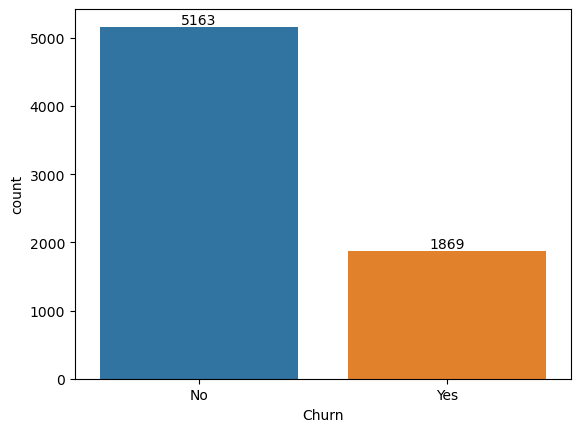

In [267]:
Aa = sns.countplot(x='Churn', data=data, hue='Churn')

for container in Aa.containers:
    Aa.bar_label(container)
    
plt.show()

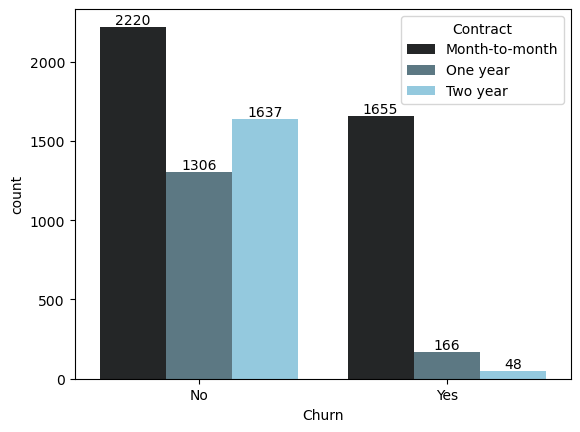

In [268]:
Ab = sns.countplot(x='Churn', data=data, hue='Contract', color='skyblue')

for container in Ab.containers:
    Ab.bar_label(container)
    
plt.show()

### Customer with monthly Contract are more likely to Churn.

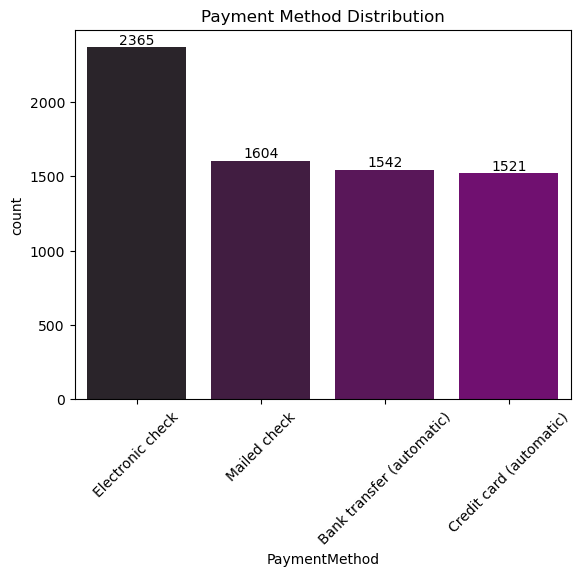

In [269]:
Ac = sns.countplot(x='PaymentMethod', data=data, hue='PaymentMethod', color='purple')

for container in Ac.containers:
    Ac.bar_label(container)
    
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

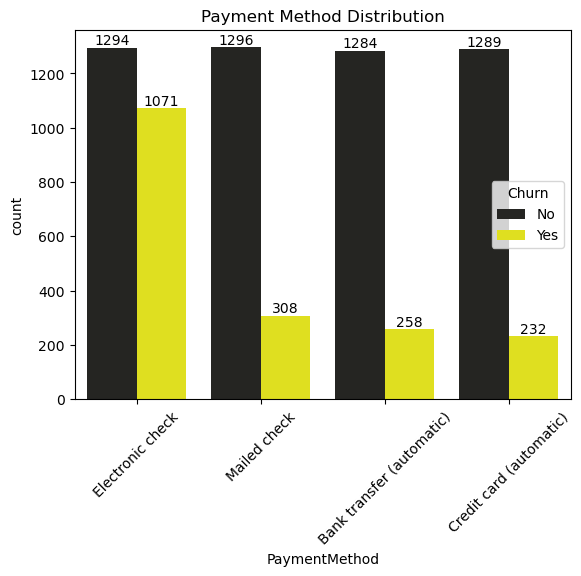

In [270]:
Ad = sns.countplot(x='PaymentMethod', data=data, hue='Churn', color='yellow')

for container in Ad.containers:
    Ad.bar_label(container)
    
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

### Customers More likes Electronic Cheque Payment Method to pay the bills 

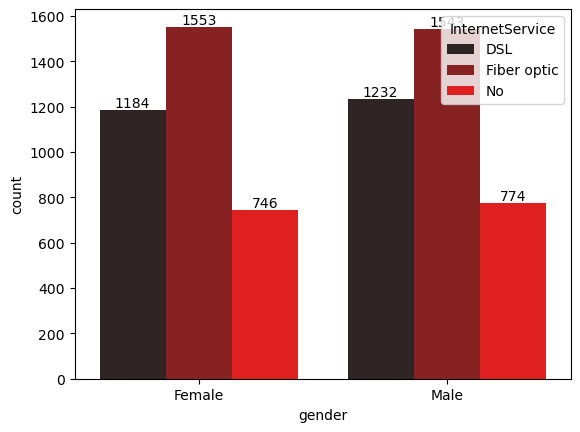

In [271]:
Ae = sns.countplot(x='gender', data=data, hue='InternetService', color='red')

for container in Ae.containers:
    Ae.bar_label(container)

plt.show()

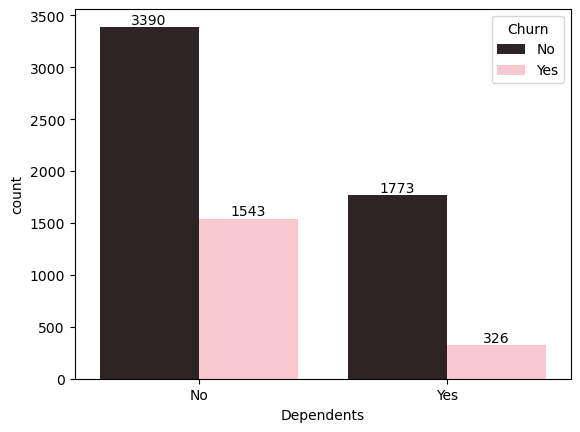

In [272]:
Af = sns.countplot(x='Dependents', data=data, hue='Churn', color='pink')

for container in Af.containers:
    Af.bar_label(container)

plt.show()

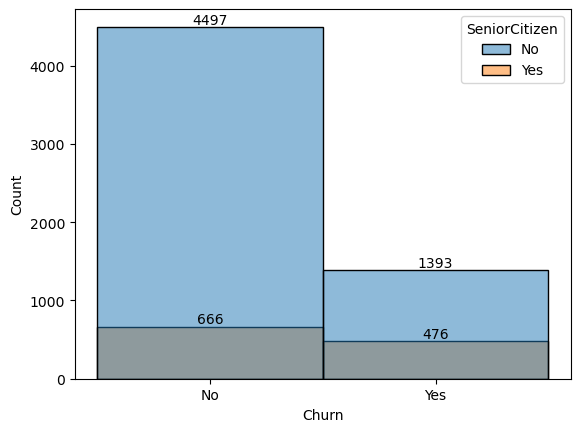

In [273]:
Ag = sns.histplot(x='Churn', data=data, hue='SeniorCitizen',)

for container in Ag.containers:
    Ag.bar_label(container)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

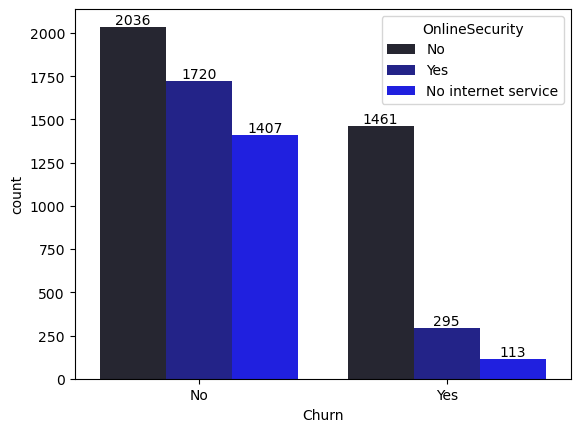

In [274]:
Ah = sns.countplot(x='Churn', data=data, hue='OnlineSecurity', color='blue')

for container in Ah.containers:
    Ah.bar_label(container)
    
plt.show

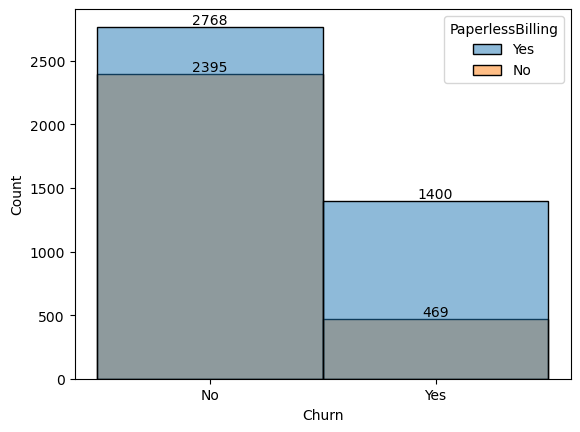

In [275]:
Ai = sns.histplot(x='Churn',data=data, hue='PaperlessBilling')

for container in Ai.containers:
    Ai.bar_label(container)

plt.show()

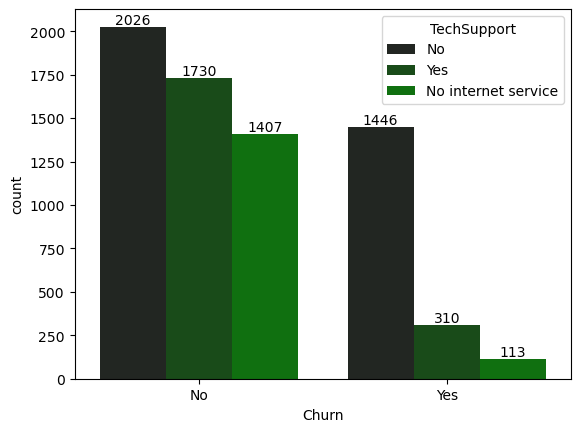

In [276]:
Aj = sns.countplot(x='Churn', data=data, hue='TechSupport', color='green')

for container in Aj.containers:
    Aj.bar_label(container)

plt.show()

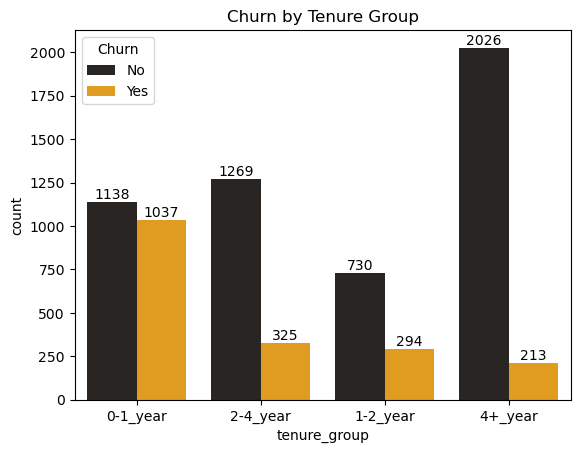

In [277]:
Ak = sns.countplot(x='tenure_group', hue='Churn', data=data, color='orange')

for container in Ak.containers:
    Ak.bar_label(container)
    
plt.title("Churn by Tenure Group")
plt.show()

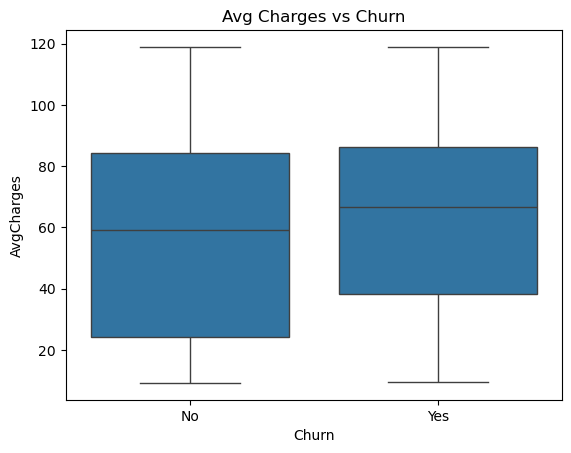

In [278]:
sns.boxplot(x='Churn', y='AvgCharges', data=data)
plt.title("Avg Charges vs Churn")
plt.show()

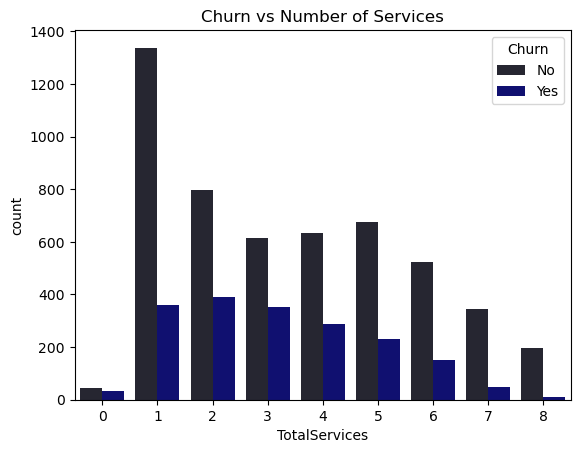

In [279]:
sns.countplot(x='TotalServices', hue='Churn', data=data, color='navy')
plt.title("Churn vs Number of Services")
plt.show()

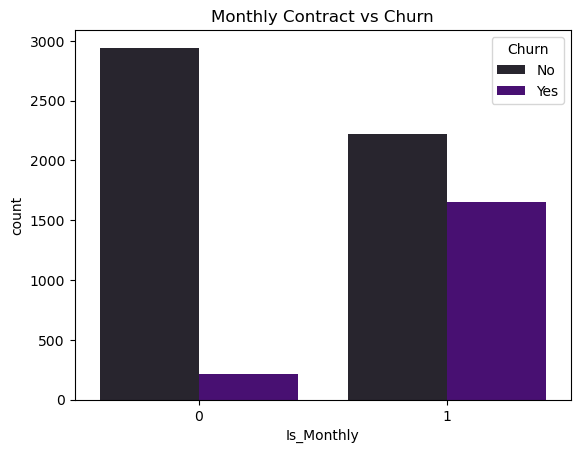

In [280]:
sns.countplot(x='Is_Monthly', hue='Churn', data=data, color='indigo')
plt.title("Monthly Contract vs Churn")
plt.show()

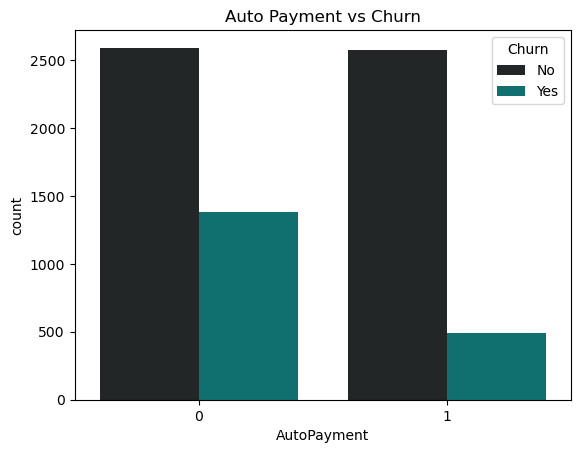

In [281]:
sns.countplot(x='AutoPayment', hue='Churn', data=data, color='teal')
plt.title("Auto Payment vs Churn")
plt.show()

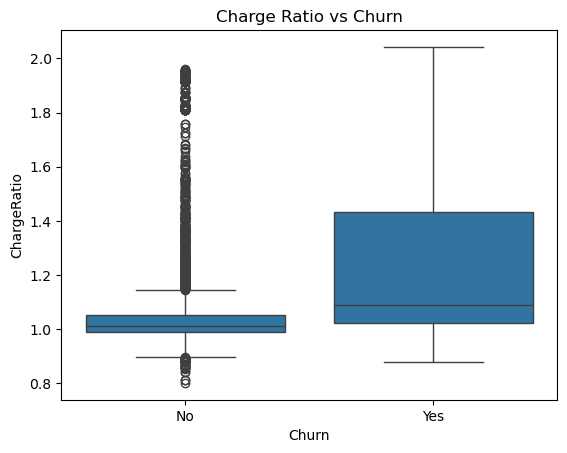

In [282]:
sns.boxplot(x='Churn', y='ChargeRatio', data=data)
plt.title("Charge Ratio vs Churn")
plt.show()

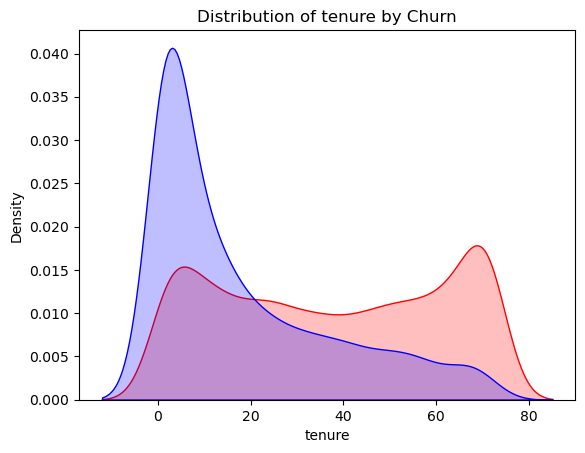

In [283]:
sns.kdeplot(data.tenure[(data["Churn"] == 'No')],color="Red", shade=True)
sns.kdeplot(data.tenure[(data["Churn"] == 'Yes')],color="Blue", shade=True)
plt.title("Distribution of tenure by Churn")
plt.show()

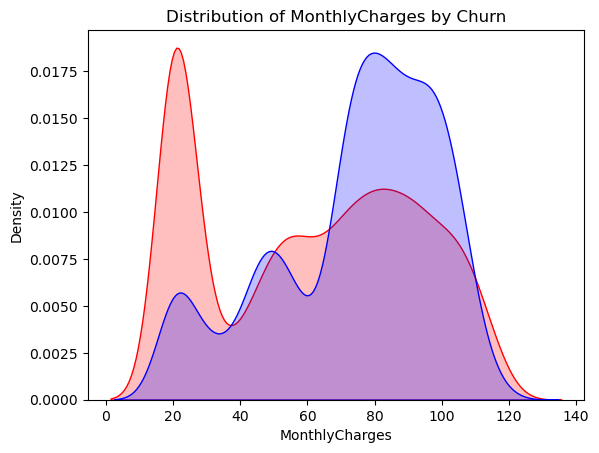

In [284]:
sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'No')],color="Red", shade=True)
sns.kdeplot(data.MonthlyCharges[(data["Churn"] == 'Yes')],color="Blue", shade=True)
plt.title("Distribution of MonthlyCharges by Churn")
plt.show()

### Customers with higher monthly charges are more likely to churn

Text(0, 0.5, 'Values')

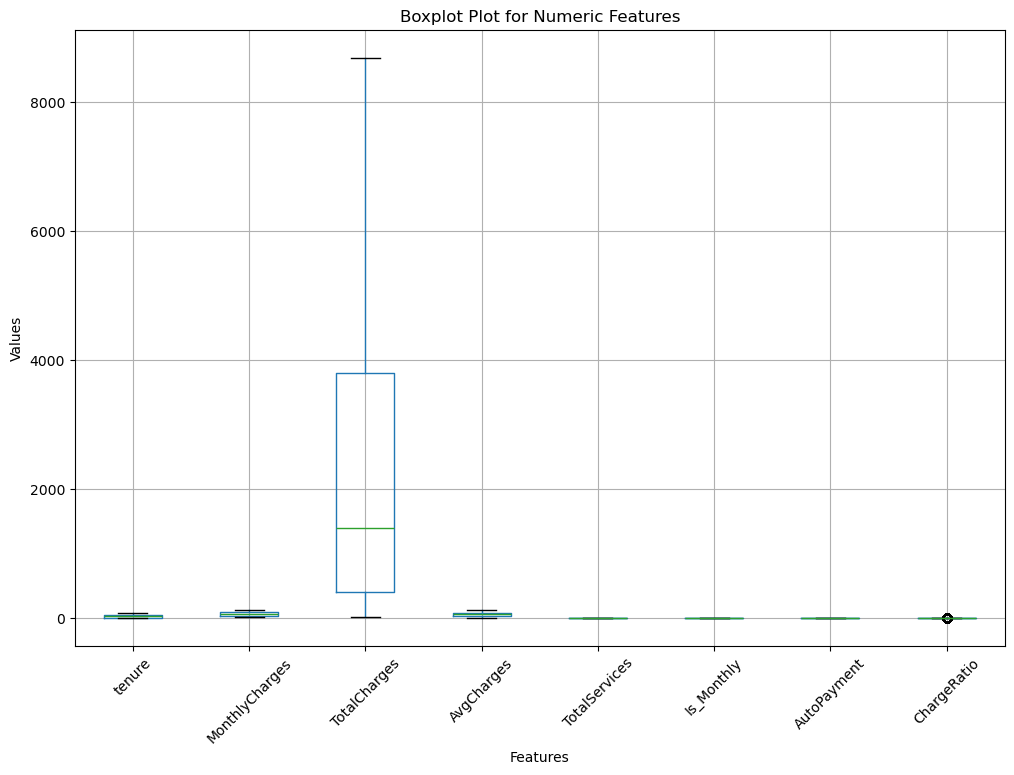

In [285]:
Numeric_Cols = data.select_dtypes(include=['int','float']).columns
plt.figure(figsize=(12,8))
data[Numeric_Cols].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot Plot for Numeric Features')
plt.xlabel('Features')
plt.ylabel('Values')

### The Analysis indicates the numeric data does not contain any outliers, removal of outliers is not required.

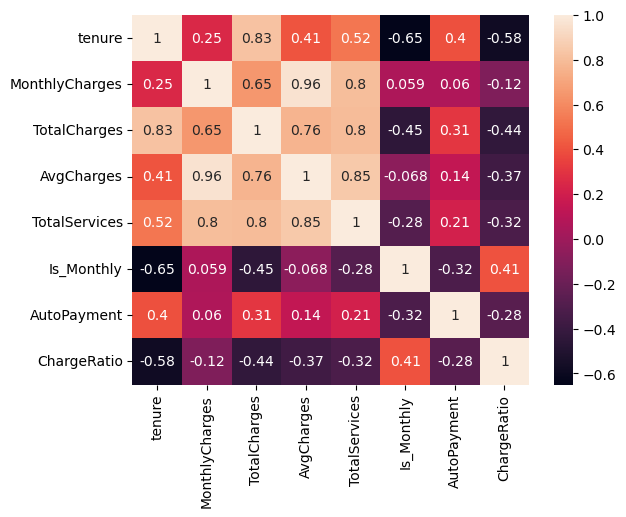

In [286]:
sns.heatmap(data.select_dtypes(include=['int','float']).corr(),annot=True)
plt.show()

In [287]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,AvgCharges,TotalServices,Is_Monthly,AutoPayment,ChargeRatio
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,No,0-1_year,14.925000,1,1,0,1.874411
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,No,2-4_year,53.985714,3,0,0,1.035724
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,Yes,0-1_year,36.050000,3,1,0,1.453441
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,No,2-4_year,40.016304,3,0,1,1.031297
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,Yes,0-1_year,50.550000,1,1,0,1.371484


In [288]:
print(data.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'AvgCharges',
       'TotalServices', 'Is_Monthly', 'AutoPayment', 'ChargeRatio'],
      dtype='object')


In [289]:
data = pd.DataFrame(data)

colums_encode = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                 'PhoneService', 'MultipleLines', 'InternetService', 
                 'OnlineSecurity','OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV','StreamingMovies', 'Contract',
                 'PaperlessBilling', 'PaymentMethod', 'Churn', 'tenure_group']

le = LabelEncoder()

for col in colums_encode:
    data[col] = le.fit_transform(data[col])

print(data)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  ...  \
0                 1                0

In [290]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,AvgCharges,TotalServices,Is_Monthly,AutoPayment,ChargeRatio
0,0,0,1,0,1,0,1,0,0,2,...,2,29.85,29.85,0,0,14.925000,1,1,0,1.874411
1,1,0,0,0,34,1,0,0,2,0,...,3,56.95,1889.50,0,2,53.985714,3,0,0,1.035724
2,1,0,0,0,2,1,0,0,2,2,...,3,53.85,108.15,1,0,36.050000,3,1,0,1.453441
3,1,0,0,0,45,0,1,0,2,0,...,0,42.30,1840.75,0,2,40.016304,3,0,1,1.031297
4,0,0,0,0,2,1,0,1,0,0,...,2,70.70,151.65,1,0,50.550000,1,1,0,1.371484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,...,3,84.80,1990.50,0,1,79.620000,7,0,0,1.051848
7039,0,0,1,1,72,1,2,1,0,2,...,1,103.20,7362.90,0,3,100.861644,6,0,1,1.013139
7040,0,0,1,1,11,0,1,0,2,0,...,2,29.60,346.45,0,0,28.870833,1,1,0,0.990933
7041,1,1,1,0,4,1,2,1,0,0,...,3,74.40,306.60,1,0,61.320000,2,1,0,1.193838


In [291]:
data.select_dtypes(include='number').corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,AvgCharges,TotalServices,Is_Monthly,AutoPayment,ChargeRatio
gender,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.006908,-0.002236,-0.014899,-0.011920,...,0.016942,-0.013779,0.000048,-0.008545,0.005154,-0.012299,-0.015931,-0.003251,-0.011974,0.011628
SeniorCitizen,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.146287,-0.032160,-0.127937,-0.013355,...,-0.038158,0.219874,0.102411,0.150541,0.023317,0.201585,0.095943,0.137752,-0.033775,-0.002588
Partner,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,0.142717,0.000513,0.150610,0.153045,...,-0.156232,0.097825,0.319072,-0.149982,0.363275,0.170315,0.220032,-0.280202,0.161327,-0.267760
Dependents,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.024975,0.044030,0.151198,0.090231,...,-0.041989,-0.112343,0.064653,-0.163128,0.156880,-0.065433,0.021304,-0.229715,0.094464,-0.133664
tenure,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.343673,-0.029835,0.327283,0.372434,...,-0.370087,0.246862,0.825880,-0.354049,0.961134,0.412135,0.524441,-0.649346,0.396772,-0.583762
PhoneService,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,-0.020504,0.387266,-0.014163,0.024040,...,-0.005499,0.248033,0.113008,0.011691,0.005827,0.221630,0.128129,-0.001243,0.001159,0.002980
MultipleLines,-0.006908,0.146287,0.142717,-0.024975,0.343673,-0.020504,1.000000,-0.108849,0.007306,0.117276,...,-0.176598,0.433905,0.453202,0.038043,0.326885,0.472813,0.520801,-0.091829,0.117337,-0.227951
InternetService,-0.002236,-0.032160,0.000513,0.044030,-0.029835,0.387266,-0.108849,1.000000,-0.028003,0.036735,...,0.084504,-0.322173,-0.175691,-0.047097,-0.027926,-0.295860,-0.372098,-0.079603,-0.040351,-0.023497
OnlineSecurity,-0.014899,-0.127937,0.150610,0.151198,0.327283,-0.014163,0.007306,-0.028003,1.000000,0.184942,...,-0.096593,-0.053576,0.254473,-0.289050,0.300637,0.029837,0.288214,-0.363857,0.183953,-0.220865
OnlineBackup,-0.011920,-0.013355,0.153045,0.090231,0.372434,0.024040,0.117276,0.036735,0.184942,1.000000,...,-0.125534,0.119943,0.375556,-0.195290,0.352117,0.196971,0.392464,-0.279371,0.159753,-0.239139


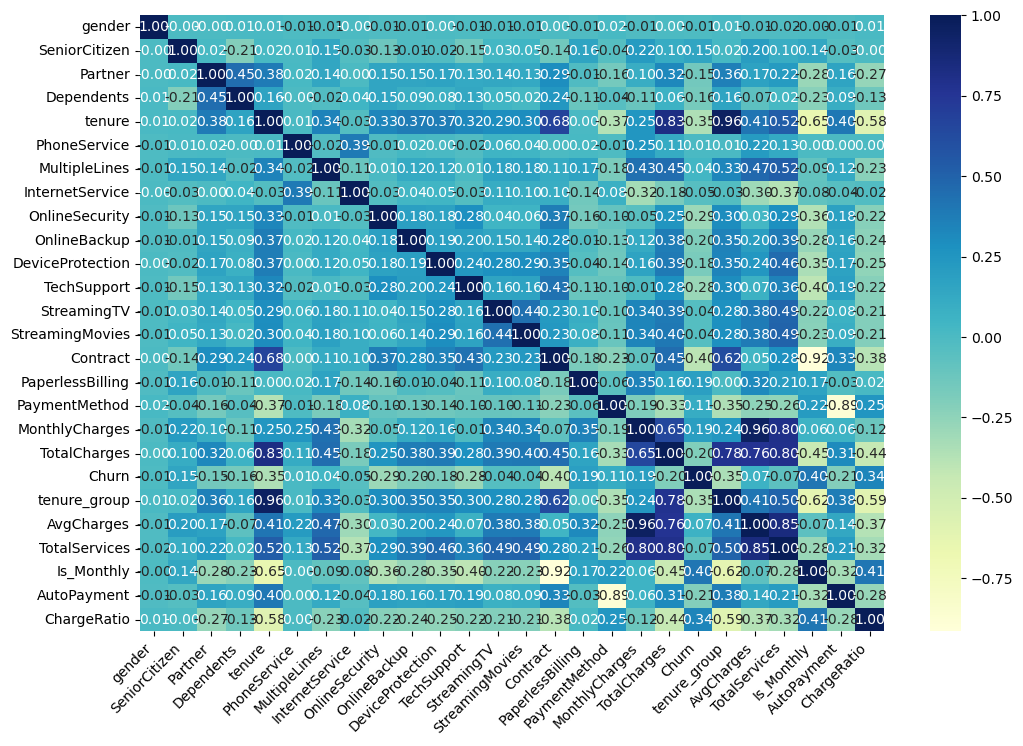

In [292]:
plt.figure(figsize=[12,8])
numeric_data = data.select_dtypes(include=['int', 'float'])
sns.heatmap(numeric_data.corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.xticks(rotation=45, horizontalalignment='right')
plt.show()

Text(0, 0.5, 'Count')

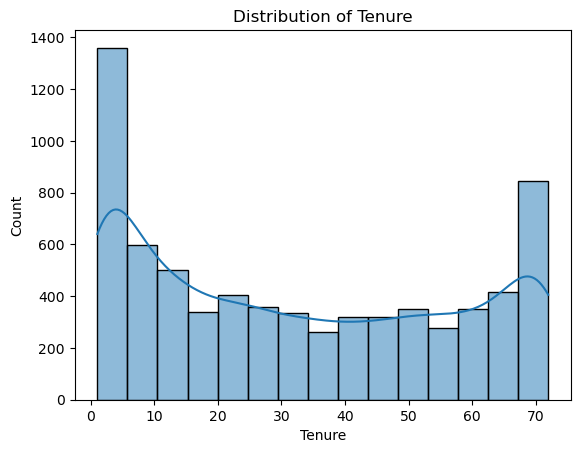

In [293]:
sns.histplot(data.tenure,kde=1)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

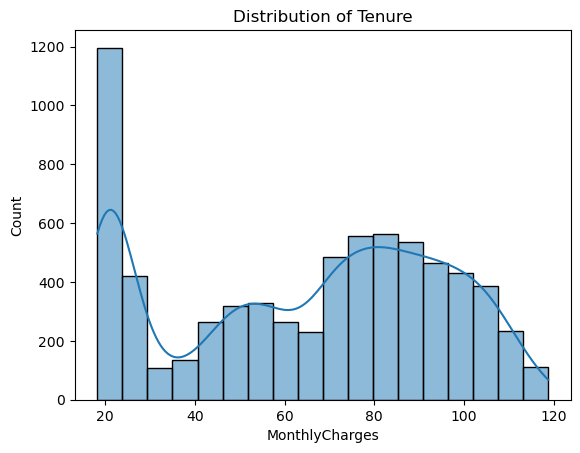

In [294]:
sns.histplot(data.MonthlyCharges,kde=1)
plt.title('Distribution of Tenure')
plt.xlabel('MonthlyCharges')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

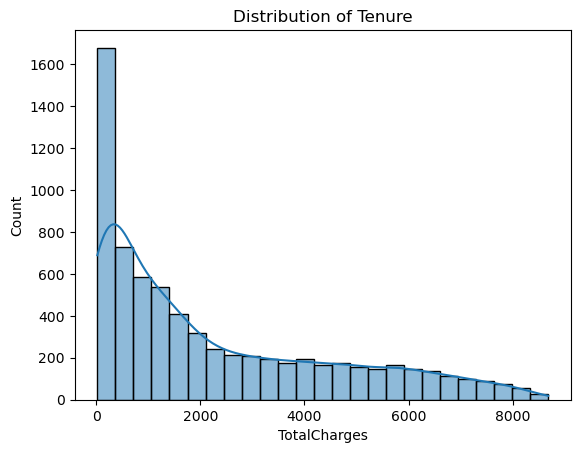

In [295]:
sns.histplot(data.TotalCharges,kde=1)
plt.title('Distribution of Tenure')
plt.xlabel('TotalCharges')
plt.ylabel('Count')

### The features need standard scaling as all of them are distributed over different range values 

In [296]:
print(data.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group', 'AvgCharges',
       'TotalServices', 'Is_Monthly', 'AutoPayment', 'ChargeRatio'],
      dtype='object')


In [297]:
col_scale = ['tenure','MonthlyCharges','TotalCharges']

scaler = StandardScaler()
data[col_scale] = scaler.fit_transform(data[col_scale])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,AvgCharges,TotalServices,Is_Monthly,AutoPayment,ChargeRatio
0,0,0,1,0,-1.280248,0,1,0,0,2,...,2,-1.161694,-0.994194,0,0,14.925000,1,1,0,1.874411
1,1,0,0,0,0.064303,1,0,0,2,0,...,3,-0.260878,-0.173740,0,2,53.985714,3,0,0,1.035724
2,1,0,0,0,-1.239504,1,0,0,2,2,...,3,-0.363923,-0.959649,1,0,36.050000,3,1,0,1.453441
3,1,0,0,0,0.512486,0,1,0,2,0,...,0,-0.747850,-0.195248,0,2,40.016304,3,0,1,1.031297
4,0,0,0,0,-1.239504,1,0,1,0,0,...,2,0.196178,-0.940457,1,0,50.550000,1,1,0,1.371484


Text(0, 0.5, 'Count')

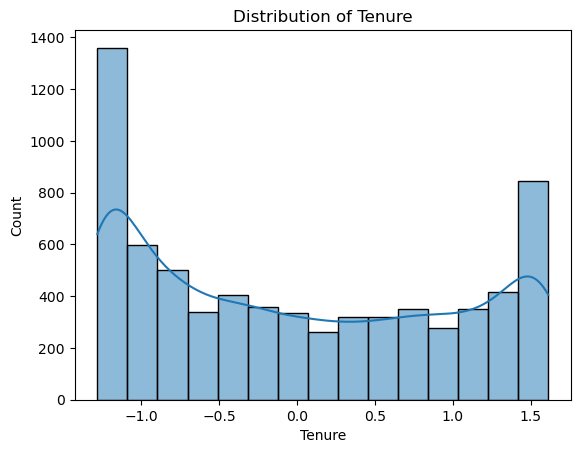

In [298]:
sns.histplot(data.tenure,kde=1)
plt.title('Distribution of Tenure')
plt.xlabel('Tenure')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

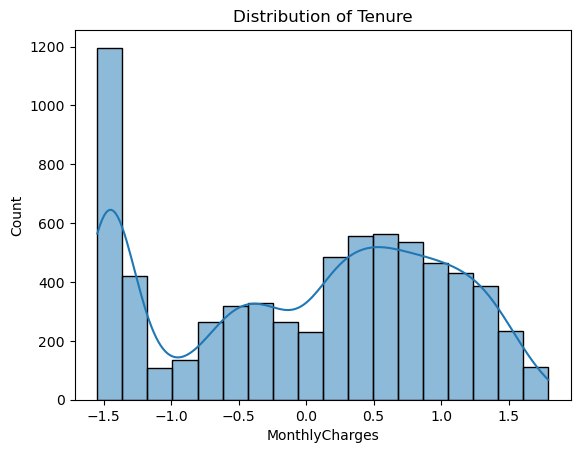

In [299]:
sns.histplot(data.MonthlyCharges,kde=1)
plt.title('Distribution of Tenure')
plt.xlabel('MonthlyCharges')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

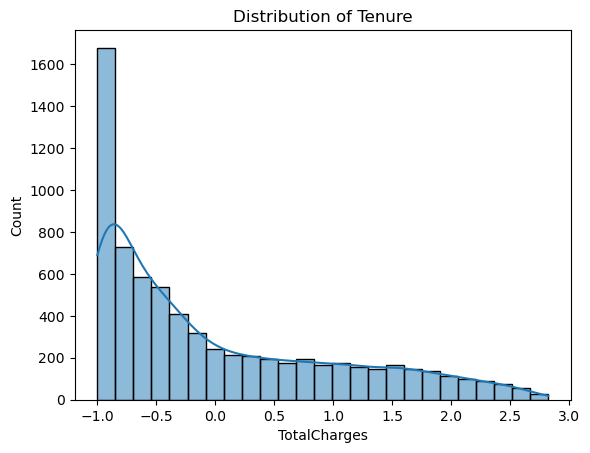

In [300]:
sns.histplot(data.TotalCharges,kde=1)
plt.title('Distribution of Tenure')
plt.xlabel('TotalCharges')
plt.ylabel('Count')

## Train & Test Split

In [301]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Building

In [302]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [303]:
lore = LogisticRegression(max_iter = 1000)
lore.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Evaluting Model

In [304]:
print("Accuracy:", accuracy_score(y_test, y_pred_lore))
print(confusion_matrix(y_test, y_pred_lore))
print(classification_report(y_test, y_pred_lore))

Accuracy: 0.7924662402274343
[[923 110]
 [182 192]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.78      1407



### Random Forcast

In [305]:
rafo = RandomForestClassifier(n_estimators=200, random_state=42)
rafo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [306]:
print(classification_report(y_test, y_pred_refo))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [307]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = loa

In [308]:
lr_pred = lore.predict(X_test_scaled)
rf_pred = rafo.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [309]:
print("Logistic Regression\n", classification_report(y_test, lr_pred))
print("Random Forest\n", classification_report(y_test, rf_pred))
print("XGBoost\n", classification_report(y_test, xgb_pred))

Logistic Regression
               precision    recall  f1-score   support

           0       0.83      0.85      0.84      1033
           1       0.55      0.51      0.53       374

    accuracy                           0.76      1407
   macro avg       0.69      0.68      0.68      1407
weighted avg       0.75      0.76      0.76      1407

Random Forest
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

XGBoost
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.52      0.55       374

    accuracy                           0.78      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      

In [310]:
lr_auc = roc_auc_score(y_test, lore.predict_proba(X_test_scaled)[:,1])
rf_auc = roc_auc_score(y_test, rafo.predict_proba(X_test)[:,1])
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print("lr_auc :", lr_auc)
print("rf_auc :", rf_auc)
print("xgb_auc :", xgb_auc)

lr_auc : 0.8083925641012367
rf_auc : 0.8169368072847374
xgb_auc : 0.8098187616153564


In [311]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC_AUC': [lr_auc, rf_auc, xgb_auc]
})

print(results)

                 Model   ROC_AUC
0  Logistic Regression  0.808393
1        Random Forest  0.816937
2              XGBoost  0.809819


### RandomForestClassifire outperformed other models in ROC-AUC and recall, making it the best choice for churn prediction.

### __Feature Importance__

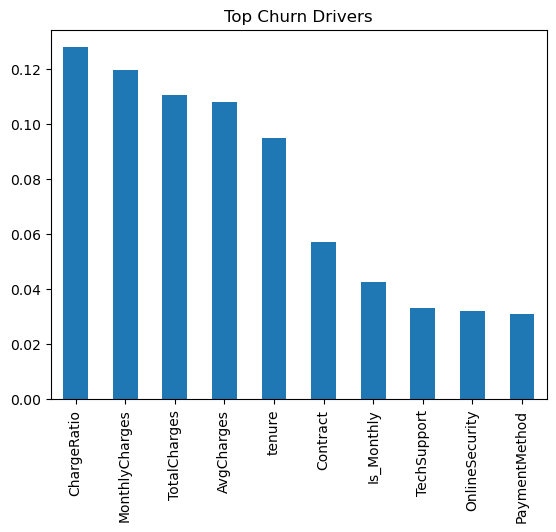

In [312]:
importances = pd.Series(rafo.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Churn Drivers")
plt.show()

In [313]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid,
                       cv=3,
                       scoring='roc_auc')

grid_rf.fit(X_train, y_train)

print(grid_rf.best_params_)

{'max_depth': 5, 'n_estimators': 200}


# __Model Save__

In [314]:
# Save model
pickle.dump(rafo, open('churn_model.pkl', 'wb'))

# Save scaler (IMPORTANT if used)
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [315]:
model = pickle.load(open('churn_model.pkl', 'rb'))

In [316]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', scaler),
    ('model', rafo)
])

pipeline.fit(X_train, y_train)

pickle.dump(pipeline, open('pipeline.pkl', 'wb'))

In [317]:
model = pickle.load(open('pipeline.pkl', 'rb'))

## Thank You